In [ ]:
#### ChatGPT was used to help write this code

In [1]:
## imports
from matplotlib_venn import venn3_unweighted
import matplotlib.pyplot as plt
from itertools import combinations
from upsetplot import UpSet, from_memberships
import warnings
import pandas as pd
import statsmodels.api as sm

In [2]:
# ALL FEATS
all_feats = ['HRk', 'HAvAge', 'HW', 'HL', 'HOL', 'HPTS%', 'HSOW', 'HSOL', 'HSRS', 'HSOS', 'HGF/G', 
       'HGA/G', 'HPP', 'HPPO', 'HPPA', 'HPPOA', 'HSH', 'HSHA', 'HPIM/G', 'HoPIM/G', 'HS%', 
       'HSV%', 'HSO', 'HCAN', 'VRk', 'VAvAge', 'VW', 'VL', 'VOL', 'VPTS%', 'VSOW', 'VSOL', 
       'VSRS', 'VSOS', 'VGF/G', 'VGA/G', 'VPP', 'VPPO', 'VPPA', 'VPPOA', 'VPK%', 'VSH', 'VSHA', 
       'VPIM/G', 'VoPIM/G', 'VS%', 'VSV%', 'VSO', 'VCAN', 'MDAY', 'TDAY', 'WDAY', 'ThDAY', 
       'FDAY', 'SDAY', 'SuDAY', 'DIV', 'CAP', 'LCAP', 'PA', 'HSTAR', 'VSTAR']

In [3]:
# LASSO SELECTED FEATS (FULL LIST)
lasso_a = ['HRk', 'HAvAge', 'HW', 'HL', 'HOL', 'HSOW', 'HSOL', 'HSRS', 'HSOS', 'HGA/G', 'HPP', 
           'HPPO', 'HPPA', 'HPPOA', 'HSH', 'HSHA', 'HPIM/G', 'HS%', 'HSV%', 'HSO', 'HCAN', 'VRk', 
           'VAvAge', 'VL', 'VOL', 'VSOW', 'VSOL', 'VSOS', 'VGA/G', 'VPP', 'VPPO', 'VPPA', 'VSH', 
           'VSHA', 'VPIM/G', 'VoPIM/G', 'VS%', 'VSV%', 'VSO', 'VCAN', 'MDAY', 'TDAY', 'WDAY', 
           'FDAY', 'SDAY', 'SuDAY', 'DIV', 'CAP', 'HSTAR', 'VSTAR']

lasso_pa = ['HRk', 'HAvAge', 'HW', 'HL', 'HOL', 'HSOW', 'HSOL', 'HSRS', 'HSOS', 'HGA/G', 'HPP', 
            'HPPO', 'HPPA', 'HPPOA', 'HSH', 'HSHA', 'HPIM/G', 'HoPIM/G', 'HS%', 'HSV%', 'HSO', 
            'HCAN', 'VRk', 'VAvAge', 'VL', 'VOL', 'VSOW', 'VSOL', 'VSOS', 'VGA/G', 'VPP', 'VPPO', 
            'VPPA', 'VPPOA', 'VSH', 'VSHA', 'VPIM/G', 'VoPIM/G', 'VS%', 'VSV%', 'VSO', 'VCAN', 
            'MDAY', 'TDAY', 'WDAY', 'FDAY', 'SDAY', 'SuDAY', 'DIV', 'CAP', 'HSTAR', 'VSTAR']

lasso_la = ['HRk', 'HAvAge', 'HW', 'HL', 'HOL', 'HSOW', 'HSOL', 'HSRS', 'HSOS', 'HGA/G', 'HPP', 
            'HPPO', 'HPPA', 'HPPOA', 'HSH', 'HSHA', 'HPIM/G', 'HS%', 'HSV%', 'HSO', 'HCAN', 
            'VRk', 'VAvAge', 'VOL', 'VSOW', 'VSOL', 'VSOS', 'VPP', 'VPPA', 'VSH', 'VSHA', 'VPIM/G', 
            'VoPIM/G', 'VS%', 'VSV%', 'VSO', 'VCAN', 'MDAY', 'TDAY', 'WDAY', 'FDAY', 'SDAY', 
            'SuDAY', 'DIV', 'LCAP', 'HSTAR', 'VSTAR']

In [4]:
# RF SELECTED FEATS
rf_a = ['HRk', 'HAvAge', 'HW', 'HPTS%', 'HSRS', 'HSOS', 'HGF/G', 'HGA/G', 'HPP', 'HPPA', 'HPPOA', 
        'HSH', 'HPIM/G', 'HoPIM/G', 'HS%', 'HSV%', 'VAvAge', 'VGF/G', 'VGA/G', 'VPP', 'VPPO', 
        'VPPOA', 'VPK%', 'VSH', 'VPIM/G', 'VoPIM/G', 'VS%', 'VSV%', 'SDAY', 'CAP']

rf_pa = ['HRk', 'HAvAge', 'HOL', 'HSRS', 'HSOS', 'HGF/G', 'HPP', 'HPPO', 'HPPA', 'HPPOA', 'HSH', 
         'HPIM/G', 'HoPIM/G', 'HSV%', 'VAvAge', 'VGF/G', 'VGA/G', 'VPP', 'VPPO', 'VPPOA', 'VPK%', 
         'VSH', 'VPIM/G', 'VoPIM/G', 'VS%', 'VSV%', 'SDAY', 'CAP']

rf_la = ['HRk', 'HAvAge', 'HW', 'HPTS%', 'HSRS', 'HSOS', 'HGF/G', 'HGA/G', 'HPP', 'HPPA', 'HPPOA', 
         'HSH', 'HPIM/G', 'HoPIM/G', 'HS%', 'VAvAge', 'VSOS', 'VGF/G', 'VGA/G', 'VPP', 'VPPO', 
         'VPPA', 'VPPOA', 'VPK%', 'VSH', 'VPIM/G', 'VoPIM/G', 'VS%', 'VSV%', 'SDAY', 'LCAP']

In [5]:
set_lasso_a = set(lasso_a)
set_lasso_pa = set(lasso_pa)
set_lasso_la = set(lasso_la)

set_rf_a = set(rf_a)
set_rf_pa = set(rf_pa)
set_rf_la = set(rf_la)

set_all = set(all_feats)

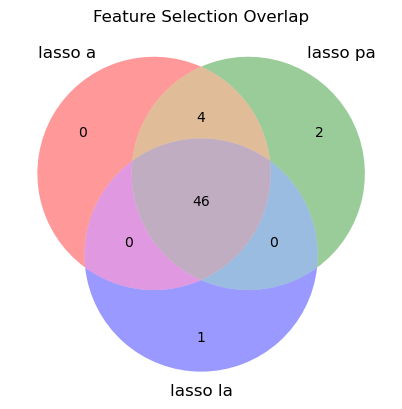

In all three: ['DIV', 'FDAY', 'HAvAge', 'HCAN', 'HGA/G', 'HL', 'HOL', 'HPIM/G', 'HPP', 'HPPA', 'HPPO', 'HPPOA', 'HRk', 'HS%', 'HSH', 'HSHA', 'HSO', 'HSOL', 'HSOS', 'HSOW', 'HSRS', 'HSTAR', 'HSV%', 'HW', 'MDAY', 'SDAY', 'SuDAY', 'TDAY', 'VAvAge', 'VCAN', 'VOL', 'VPIM/G', 'VPP', 'VPPA', 'VRk', 'VS%', 'VSH', 'VSHA', 'VSO', 'VSOL', 'VSOS', 'VSOW', 'VSTAR', 'VSV%', 'VoPIM/G', 'WDAY']

Only in lasso_a: []
Only in lasso_pa: ['HoPIM/G', 'VPPOA']
Only in lasso_la: ['LCAP']

In lasso_a and lasso_pa only: ['CAP', 'VGA/G', 'VL', 'VPPO']
In lasso_pa and lasso_la only: []
In lasso_a and lasso_la only: []


In [6]:
# shows a lot of warnings
warnings.filterwarnings("ignore", category=UserWarning)

# plot venn diagram (not to scale)
venn3_unweighted([set_lasso_a, set_lasso_pa, set_lasso_la], ('lasso a', 'lasso pa', 'lasso la'))
plt.title("Feature Selection Overlap")
plt.show()

# Unique to each set
only_in_a = set_lasso_a - set_lasso_pa - set_lasso_la
only_in_pa = set_lasso_pa - set_lasso_a - set_lasso_la
only_in_la = set_lasso_la - set_lasso_a - set_lasso_pa

# In two sets, but not all three
in_a_pa = (set_lasso_a & set_lasso_pa) - set_lasso_la
in_pa_la = (set_lasso_pa & set_lasso_la) - set_lasso_a
in_a_la = (set_lasso_a & set_lasso_la) - set_lasso_pa

# In all three
in_all_three = set_lasso_a & set_lasso_pa & set_lasso_la

# Output
print("In all three:", sorted(in_all_three))
print("\nOnly in lasso_a:", sorted(only_in_a))
print("Only in lasso_pa:", sorted(only_in_pa))
print("Only in lasso_la:", sorted(only_in_la))
print("\nIn lasso_a and lasso_pa only:", sorted(in_a_pa))
print("In lasso_pa and lasso_la only:", sorted(in_pa_la))
print("In lasso_a and lasso_la only:", sorted(in_a_la))

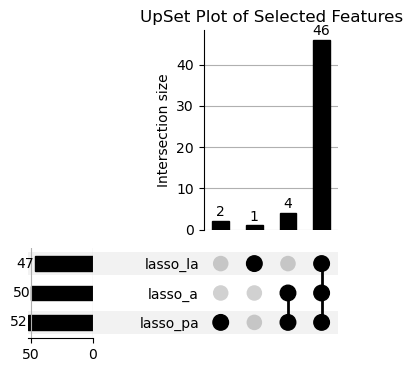

In [7]:
# shows a lot of warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# sets
sets = {
    'lasso_a': set_lasso_a,
    'lasso_pa': set_lasso_pa,
    'lasso_la': set_lasso_la,
}

# unique features
all_features = set().union(*sets.values())

# build binary membership list for each feature
memberships = []
for feature in all_features:
    present_in = [name for name, s in sets.items() if feature in s]
    memberships.append(present_in)

# create UpSet data and plot
data = from_memberships(memberships)
UpSet(data, subset_size='count', show_counts=True).plot()
plt.title("UpSet Plot of Selected Features")
plt.show()

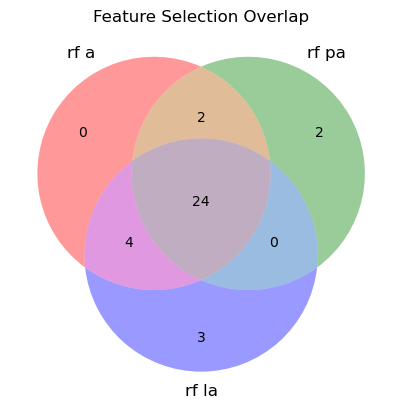

In all three: ['HAvAge', 'HGF/G', 'HPIM/G', 'HPP', 'HPPA', 'HPPOA', 'HRk', 'HSH', 'HSOS', 'HSRS', 'HoPIM/G', 'SDAY', 'VAvAge', 'VGA/G', 'VGF/G', 'VPIM/G', 'VPK%', 'VPP', 'VPPO', 'VPPOA', 'VS%', 'VSH', 'VSV%', 'VoPIM/G']

Only in rf_a: []
Only in rf_pa: ['HOL', 'HPPO']
Only in rf_la: ['LCAP', 'VPPA', 'VSOS']

In rf_a and rf_pa only: ['CAP', 'HSV%']
In rf_pa and rf_la only: []
In rf_a and rf_la only: ['HGA/G', 'HPTS%', 'HS%', 'HW']


In [8]:
venn3_unweighted([set_rf_a, set_rf_pa, set_rf_la], ('rf a', 'rf pa', 'rf la'))
plt.title("Feature Selection Overlap")
plt.show()

# Unique to each set
only_in_a = set_rf_a - set_rf_pa - set_rf_la
only_in_pa = set_rf_pa - set_rf_a - set_rf_la
only_in_la = set_rf_la - set_rf_a - set_rf_pa

# In two sets, but not all three
in_a_pa = (set_rf_a & set_rf_pa) - set_rf_la
in_pa_la = (set_rf_pa & set_rf_la) - set_rf_a
in_a_la = (set_rf_a & set_rf_la) - set_rf_pa

# In all three
in_all_three = set_rf_a & set_rf_pa & set_rf_la

# Output
print("In all three:", sorted(in_all_three))
print("\nOnly in rf_a:", sorted(only_in_a))
print("Only in rf_pa:", sorted(only_in_pa))
print("Only in rf_la:", sorted(only_in_la))
print("\nIn rf_a and rf_pa only:", sorted(in_a_pa))
print("In rf_pa and rf_la only:", sorted(in_pa_la))
print("In rf_a and rf_la only:", sorted(in_a_la))

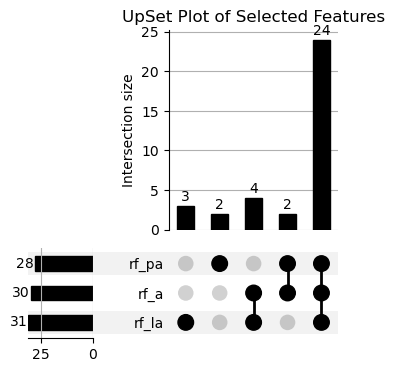

In [9]:
# shows a lot of warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# sets
sets = {
    'rf_a': set_rf_a,
    'rf_pa': set_rf_pa,
    'rf_la': set_rf_la
}

# unique features
all_features = set().union(*sets.values())

# build binary membership list for each feature
memberships = []
for feature in all_features:
    present_in = [name for name, s in sets.items() if feature in s]
    memberships.append(present_in)

# create UpSet data and plot
data = from_memberships(memberships)
UpSet(data, subset_size='count', show_counts=True).plot()
plt.title("UpSet Plot of Selected Features")
plt.show()

In [10]:
in_all_six = set_lasso_a & set_lasso_pa & set_lasso_la & set_rf_a & set_rf_pa & set_rf_la
print("In all six:", sorted(in_all_six))

only_in_lasso_a = set_lasso_a - set_lasso_pa - set_lasso_la - set_rf_a - set_rf_pa - set_rf_la
only_in_lasso_pa = set_lasso_pa - set_lasso_a - set_lasso_la - set_rf_a - set_rf_pa - set_rf_la
only_in_lasso_la = set_lasso_la - set_lasso_a - set_lasso_pa - set_rf_a - set_rf_pa - set_rf_la
only_in_rf_a = set_rf_a - set_lasso_a - set_lasso_pa - set_lasso_la - set_rf_pa - set_rf_la
only_in_rf_pa = set_rf_pa - set_lasso_a - set_lasso_pa - set_lasso_la - set_rf_a - set_rf_la
only_in_rf_la = set_rf_la - set_lasso_a - set_lasso_pa - set_lasso_la - set_rf_a - set_rf_pa

print("\nOnly in lasso_a:", sorted(only_in_lasso_a))
print("Only in lasso_pa:", sorted(only_in_lasso_pa))
print("Only in lasso_la:", sorted(only_in_lasso_la))
print("Only in rf_a:", sorted(only_in_rf_a))
print("Only in rf_pa:", sorted(only_in_rf_pa))
print("Only in rf_la:", sorted(only_in_rf_la))

lasso_union = set_lasso_a | set_lasso_pa | set_lasso_la
rf_union = set_rf_a | set_rf_pa | set_rf_la

only_lasso = lasso_union - rf_union
print("\nOnly in Lasso sets:", sorted(only_lasso))

only_rf = rf_union - lasso_union
print("\nOnly in RF sets:", sorted(only_rf))

shared_lasso_rf = lasso_union & rf_union
print("\nShared between Lasso and RF:", sorted(shared_lasso_rf))

all_sets = {
    'lasso_a': set_lasso_a,
    'lasso_pa': set_lasso_pa,
    'lasso_la': set_lasso_la,
    'rf_a': set_rf_a,
    'rf_pa': set_rf_pa,
    'rf_la': set_rf_la
}

print("\n--- Pairwise Intersections ---")
for (name1, s1), (name2, s2) in combinations(all_sets.items(), 2):
    overlap = s1 & s2
    if overlap:
        print(f"{name1} ∩ {name2} ({len(overlap)}): {sorted(overlap)}\n")

In all six: ['HAvAge', 'HPIM/G', 'HPP', 'HPPA', 'HPPOA', 'HRk', 'HSH', 'HSOS', 'HSRS', 'SDAY', 'VAvAge', 'VPIM/G', 'VPP', 'VS%', 'VSH', 'VSV%', 'VoPIM/G']

Only in lasso_a: []
Only in lasso_pa: []
Only in lasso_la: []
Only in rf_a: []
Only in rf_pa: []
Only in rf_la: []

Only in Lasso sets: ['DIV', 'FDAY', 'HCAN', 'HL', 'HSHA', 'HSO', 'HSOL', 'HSOW', 'HSTAR', 'MDAY', 'SuDAY', 'TDAY', 'VCAN', 'VL', 'VOL', 'VRk', 'VSHA', 'VSO', 'VSOL', 'VSOW', 'VSTAR', 'WDAY']

Only in RF sets: ['HGF/G', 'HPTS%', 'VGF/G', 'VPK%']

Shared between Lasso and RF: ['CAP', 'HAvAge', 'HGA/G', 'HOL', 'HPIM/G', 'HPP', 'HPPA', 'HPPO', 'HPPOA', 'HRk', 'HS%', 'HSH', 'HSOS', 'HSRS', 'HSV%', 'HW', 'HoPIM/G', 'LCAP', 'SDAY', 'VAvAge', 'VGA/G', 'VPIM/G', 'VPP', 'VPPA', 'VPPO', 'VPPOA', 'VS%', 'VSH', 'VSOS', 'VSV%', 'VoPIM/G']

--- Pairwise Intersections ---
lasso_a ∩ lasso_pa (50): ['CAP', 'DIV', 'FDAY', 'HAvAge', 'HCAN', 'HGA/G', 'HL', 'HOL', 'HPIM/G', 'HPP', 'HPPA', 'HPPO', 'HPPOA', 'HRk', 'HS%', 'HSH', 'HSHA', 'HSO',

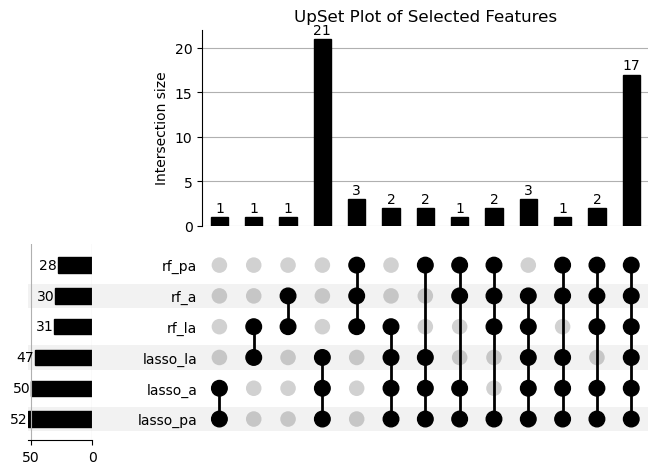

In [11]:
# this plot is confusing to understand ngl

# shows a lot of warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# sets
sets = {
    'lasso_a': set_lasso_a,
    'lasso_pa': set_lasso_pa,
    'lasso_la': set_lasso_la,
    'rf_a': set_rf_a,
    'rf_pa': set_rf_pa,
    'rf_la': set_rf_la,
}

# unique features
all_features = set().union(*sets.values())

# build binary membership list for each feature
memberships = []
for feature in all_features:
    present_in = [name for name, s in sets.items() if feature in s]
    memberships.append(present_in)

# create UpSet data and plot
data = from_memberships(memberships)
UpSet(data, subset_size='count', show_counts=True).plot()
plt.title("UpSet Plot of Selected Features")
plt.show()

In [12]:
# load data
df_att = pd.read_csv('attendance data with features.csv')

rand_seed = 34

In [13]:
# remove unnecessary features
# duplicates, linearly dependent variables, etc.

remove = ['HGP', 'VGP',
          'HPTS', 'VPTS',
          'HGF', 'VGF',
          'HGA', 'VGA',
          'HPP%', 'VPP%', 
          'HPK%', 'HPK%',
          'HS', 'VS', 
          'HSA', 'VSA']

df_att = df_att.drop(columns = remove)

In [14]:
# A, PA, CAP
df_cap = df_att.copy().drop(columns = ['LA', 'LCAP'])

# LA, LCAP
df_lcap = df_att.copy().drop(columns = ['A', 'PA','CAP'])

X_cap_a = df_att.drop(columns = ['H', 'V', 'A', 'LA', 'PA', 'LCAP'])
y_cap_a = df_att['A']

X_cap_pa = df_att.drop(columns = ['H', 'V', 'A', 'LA', 'PA', 'LCAP'])
y_cap_pa = df_att['PA']

X_lcap = df_att.drop(columns = ['H', 'V', 'A', 'LA', 'PA', 'CAP'])
y_lcap = df_att['LA']

In [15]:
#### OLS WITH LASSO SELECTED FEATS

# A

# Subset the data to include only the selected features
X_selected = X_cap_a[lasso_a]

# Add a constant term for the intercept
X_selected = sm.add_constant(X_selected)

# Run the OLS regression
ols_model = sm.OLS(y_cap_a, X_selected).fit()

# Get the p-values from the OLS model
p_values = ols_model.pvalues

# Filter for features with p-value < 0.05
# Get significant features and remove 'const' safely
sig_fig_lasso_a = [feat for feat in p_values[p_values < 0.05].index if feat != 'const']
non_sig_fig_lasso_a = [feat for feat in p_values[p_values >= 0.05].index if feat != 'const']

In [16]:
# PA

# Subset the data to include only the selected features
X_selected = X_cap_pa[lasso_pa]

# Add a constant term for the intercept
X_selected = sm.add_constant(X_selected)

# Run the OLS regression
ols_model = sm.OLS(y_cap_pa, X_selected).fit()

# Get the p-values from the OLS model
p_values = ols_model.pvalues

# Filter for features with p-value < 0.05
# Get significant features and remove 'const' safely
sig_fig_lasso_pa = [feat for feat in p_values[p_values < 0.05].index if feat != 'const']
non_sig_fig_lasso_pa = [feat for feat in p_values[p_values >= 0.05].index if feat != 'const']

In [17]:
# LA

# Subset the data to include only the selected features
X_selected = X_lcap[lasso_la]

# Add a constant term for the intercept
X_selected = sm.add_constant(X_selected)

# Run the OLS regression
ols_model = sm.OLS(y_lcap, X_selected).fit()

# Get the p-values from the OLS model
p_values = ols_model.pvalues

# Filter for features with p-value < 0.05
# Get significant features and remove 'const' safely
sig_fig_lasso_la = [feat for feat in p_values[p_values < 0.05].index if feat != 'const']
non_sig_fig_lasso_la = [feat for feat in p_values[p_values >= 0.05].index if feat != 'const']

In [18]:
#### OLS WITH RF SELECTED FEATS

# A

# Subset the data to include only the selected features
X_selected = X_cap_a[rf_a]

# Add a constant term for the intercept
X_selected = sm.add_constant(X_selected)

# Run the OLS regression
ols_model = sm.OLS(y_cap_a, X_selected).fit()

# Get the p-values from the OLS model
p_values = ols_model.pvalues

# Filter for features with p-value < 0.05
# Get significant features and remove 'const' safely
sig_fig_rf_a = [feat for feat in p_values[p_values < 0.05].index if feat != 'const']
non_sig_fig_rf_a = [feat for feat in p_values[p_values >= 0.05].index if feat != 'const']

In [19]:
#### OLS WITH RF SELECTED FEATS

# PA

# Subset the data to include only the selected features
X_selected = X_cap_pa[rf_pa]

# Add a constant term for the intercept
X_selected = sm.add_constant(X_selected)

# Run the OLS regression
ols_model = sm.OLS(y_cap_pa, X_selected).fit()

# Get the p-values from the OLS model
p_values = ols_model.pvalues

# Filter for features with p-value < 0.05
# Get significant features and remove 'const' safely
sig_fig_rf_pa = [feat for feat in p_values[p_values < 0.05].index if feat != 'const']
non_sig_fig_rf_pa = [feat for feat in p_values[p_values >= 0.05].index if feat != 'const']

In [20]:
#### OLS WITH RF SELECTED FEATS

# LA

# Subset the data to include only the selected features
X_selected = X_lcap[rf_la]

# Add a constant term for the intercept
X_selected = sm.add_constant(X_selected)

# Run the OLS regression
ols_model = sm.OLS(y_lcap, X_selected).fit()

# Get the p-values from the OLS model
p_values = ols_model.pvalues

# Filter for features with p-value < 0.05
# Get significant features and remove 'const' safely
sig_fig_rf_la = [feat for feat in p_values[p_values < 0.05].index if feat != 'const']
non_sig_fig_rf_la = [feat for feat in p_values[p_values >= 0.05].index if feat != 'const']

In [21]:
# unique significant features
# Combine all lists into one list
all_sig = (sig_fig_lasso_a + sig_fig_lasso_a + sig_fig_lasso_a) + (sig_fig_rf_a + sig_fig_rf_pa + sig_fig_rf_la)

# Convert the combined list to a set to get unique features
unique_sig = list(set(all_sig))
print(f'Unique Features with p < 0.05: {unique_sig}\nNumber of Features: {len(unique_sig)}')

# unique non-significant features
all_non_sig = (non_sig_fig_lasso_a + non_sig_fig_lasso_a + non_sig_fig_lasso_a) + (non_sig_fig_rf_a + non_sig_fig_rf_pa + non_sig_fig_rf_la)

# Convert the combined list to a set to get unique features
unique_non_sig = list(set(all_non_sig))
print(f'\nUnique Features with p >= 0.05: {unique_non_sig}\nNumber of Features: {len(unique_non_sig)}')

# Features only in significant set (not in non-significant)
only_sig = list(set(unique_sig) - set(unique_non_sig))
print(f'\nFeatures only in significant: {only_sig}\nNumber: {len(only_sig)}')

# Features only in non-significant set (not in significant)
only_non_sig = list(set(unique_non_sig) - set(unique_sig))
print(f'\nFeatures only in non-significant: {only_non_sig}\nNumber: {len(only_non_sig)}')

Unique Features with p < 0.05: ['HPPO', 'VL', 'HOL', 'HCAN', 'HGF/G', 'HSHA', 'LCAP', 'HL', 'FDAY', 'HSOS', 'VRk', 'HSTAR', 'HSV%', 'HSO', 'HW', 'HGA/G', 'SDAY', 'HPPOA', 'HSH', 'VPPO', 'HAvAge', 'HPP', 'HS%', 'CAP', 'HRk', 'HPIM/G', 'HPTS%', 'DIV', 'SuDAY', 'TDAY', 'HSRS', 'HPPA', 'HSOW']
Number of Features: 33

Unique Features with p >= 0.05: ['WDAY', 'MDAY', 'HPPO', 'VoPIM/G', 'VPK%', 'HOL', 'VSTAR', 'VPPOA', 'VGA/G', 'VPIM/G', 'VSOL', 'HSOS', 'VSV%', 'VCAN', 'VPPA', 'HW', 'VPP', 'VPPO', 'HSH', 'HPP', 'VSOW', 'HSOL', 'VSO', 'VS%', 'VGF/G', 'VOL', 'HoPIM/G', 'VAvAge', 'VSH', 'VSHA', 'VSOS']
Number of Features: 31

Features only in significant: ['VL', 'HCAN', 'HGF/G', 'HSHA', 'LCAP', 'HL', 'FDAY', 'VRk', 'HSTAR', 'HSV%', 'HSO', 'HGA/G', 'SDAY', 'HPPOA', 'HAvAge', 'CAP', 'HS%', 'HRk', 'HPIM/G', 'HPTS%', 'DIV', 'SuDAY', 'TDAY', 'HSRS', 'HPPA', 'HSOW']
Number: 26

Features only in non-significant: ['WDAY', 'MDAY', 'VoPIM/G', 'VPK%', 'VSTAR', 'VPPOA', 'VGA/G', 'VPIM/G', 'VSOL', 'VSV%', 'V

In [22]:
combined = list(set(list(in_all_six) + unique_sig))
ordered_combined = [feat for feat in all_feats if feat in combined]
print(f'Final Feature Selection (Ordered): {ordered_combined}')

Final Feature Selection (Ordered): ['HRk', 'HAvAge', 'HW', 'HL', 'HOL', 'HPTS%', 'HSOW', 'HSRS', 'HSOS', 'HGF/G', 'HGA/G', 'HPP', 'HPPO', 'HPPA', 'HPPOA', 'HSH', 'HSHA', 'HPIM/G', 'HS%', 'HSV%', 'HSO', 'HCAN', 'VRk', 'VAvAge', 'VL', 'VPP', 'VPPO', 'VSH', 'VPIM/G', 'VoPIM/G', 'VS%', 'VSV%', 'TDAY', 'FDAY', 'SDAY', 'SuDAY', 'DIV', 'CAP', 'LCAP', 'HSTAR']
